Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on ${}^{151}Eu$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy

In [2]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)

(36, 3)
6 1 6


In [3]:
#M tensor ground state
M = np.matrix(np.diag([0.443,0.5682,1.1193]))#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = -1*np.matrix(np.diag([-2.735,2.735,12.3797]))*1E6*spin.h

print(Q/(1E6*spin.h))

#rotated tensors
M_rot = np.array([144.9,34.9,98.1])*np.pi/180

M_G = spin.tensorRotation(M,M_rot)
Q_G = spin.tensorRotation(Q,np.array([-39.3,76.49,149.9])*np.pi/180)

print('Q',Q_G/(1E6*spin.h))
print(M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
ground.setgN(M_G)
#print(ground.H.shape)

[[  2.735    0.       0.    ]
 [  0.      -2.735    0.    ]
 [  0.       0.     -12.3797]]
Q [[-11.60495785   1.20563315  -2.8496342 ]
 [  1.20563315  -2.81723096   1.06908649]
 [ -2.8496342    1.06908649   2.04248881]]
[[ 0.73420331  0.30694525 -0.08852053]
 [ 0.30694525  0.86172151 -0.01485086]
 [-0.08852053 -0.01485086  0.53457517]]


Mainloop for each B field value the following is performed:
- The B field is converted from spherical to cartesian coordinates
- We calculate our total hamiltonian consisting of the static hyperfine and/or quadrapole and the dynamic zeeman terms.
- We calculate the eigenvalues and eigenvectors of the hamiltonian, converting the eigenvalues to frequencies.
- We calculate the transition strength between each energy level based on the eigenvectors of the excited and ground states
- We calculate the spin transition probabilities based on the dynamic hamiltonian.

In [4]:
theta,phi = spin.eulerToSphere(M_rot,str='ZXZ')
theta = 1*np.pi/2
phi=0*np.pi/2

#setup the loop, here it is easier to run the loop outside of the class
thetas = [theta+0*np.pi/180]#note we apply a small pertubation to our angle to better match experiments
phis = [phi]

thetas=np.pi/2*np.linspace(-1,1,int(1E2))
phis=np.pi/2*np.linspace(-1,1,int(1E2))
Bs=np.linspace(0E-3,3.5,100)
#Bs=[0,0.1]


#sets the default dynamic term as both electronic and nuclear zeeman
FreqG = ground.initSweep(thetas,phis,Bs)

#OS = ground.initSweep(thetas,phis,Bs,ground.dim**2)
#OS_SG = ground.initSweep(thetas,phis,Bs,ground.dim)
OS_SG = np.zeros((len(thetas),len(phis),len(Bs),ground.dim,3),dtype = np.csingle)#

CS_G = ground.initSweep(thetas,phis,Bs,ground.dim)
#CS_G = np.zeros((len(thetas),len(phis),len(Bs),3,3))

Bac = np.matrix([1,1,1]).T

BC = np.eye(3)
#print('Q',Q_G)
Is = spin.spinOperator(Ispin,matricies=True)

As = spin.genAMatrix(spin.muN*M_G,Is)

#off= np.matrix([-0.535,-0.634,0.558]).T
off= np.matrix([0,0,0]).T

#print(As[0])
#print(As)

#our loop
for i in range(len(thetas)):
    for j in range(len(phis)):
        for k in range(len(Bs)):
            #convert spherical Magnetic field to cartesian coords.
            B =spin.sphereCart(Bs[k],thetas[i],phis[j])+Bs[k]*off
            #print(B)
            #Calculate our hamiltonian at this B Field
            HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
            #HG = H+ground.nuclearZeeman(B)#/spin.muN
            
            #get the eigen frequencies and vectors at this B field
            FG,VG = ground.getEigFreq(HG)
            FreqG[i,j,k,:]=FG*1E3
            
            #print(Am.shape,VG.shape)
            for l in range(3):
                #print(l)
                OS_SG[i,j,k,:,l] = ground.firstOrderSensitivity(VG,As[l]/spin.muN)*spin.muN
            #OS[i,j,k,:] = ground.TransitionStrength(VG,Am)
            CS_G[i,j,k,:]=ground.curvatureCalculation(As[0],As[1],As[2],VG,FG,indiv=True)
            #print(S)
            
            A = lambda B: ground.nuclearZeeman(B)
            #CS_G[i,j,k,:]=ground.curvatureCalculationAlt(A,BC,VG,FG,indiv=True)

            #try:
            #E = np.linalg.eigvalsh(S)
            #E = E[np.abs(E).argmax()]
            #print(E.shape)
            #except np.:
            #    print("Broken!")
            #    E = -1
            #CS_G[i,j,k,:,:]= E
pass

Plotting of energy levels for both the ground and excited state.

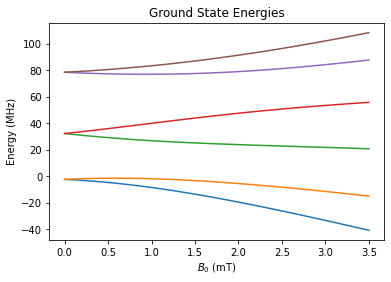

In [5]:

#Plot our energy levels
F_S = np.squeeze(np.real(FreqG[0,0,:,:]))
plt.plot(Bs,F_S)
plt.title("Ground State Energies")
plt.xlabel(r"$B_{0}$ (mT)")
plt.ylabel("Energy (MHz)")
plt.show()
plt.close()

# ZEFOZ notes:
Critical points occur when:
$$\frac{\partial f_{nm}}{\partial B_{i}} = \left<\psi_{n}\right|A_{i}\left|\psi_{m}\right>=0$$

Our sensitivity is the extension:
$$\vec{S}_{1} = \frac{\partial f_{nm}}{\partial B_{x}}\vec{i}+\frac{\partial f_{nm}}{\partial B_{y}}\vec{j}+\frac{\partial f_{nm}}{\partial B_{z}}\vec{k}$$

Maximum curvature given by the largest eigenvalue of $S_{2}$
$$\vec{S}_{2} = \begin{pmatrix}\frac{\partial^2 f}{\partial B_{x}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{y}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{z}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{z}}\end{pmatrix}$$

Where
$$\frac{\partial^2 f}{\partial B_{i}\partial B_{j}} =\sum_{m\neq n}\frac{1}{f_{n}-f_{m}}\left[\left<\psi_{m}\right|A_{i}\left|\psi_{n}\right>\left<\psi_{n}\right|A_{j}\left|\psi_{m}\right>+c.c.\right]+G_{i,j}+G_{j,i} $$

This gives our $T_{2}$ time at a ZEFOZ point:
$$\frac{1}{\pi T_{2}} = \vec{S}_{1}\cdot\Delta\vec{B}+\Delta\vec{B}\cdot\vec{S}_{2}\cdot\Delta\vec{B}$$

(100, 6, 3)
(100, 6)
Cartesian Coords:  [[-6.123234e-17  1.000000e+00  6.123234e-17]]


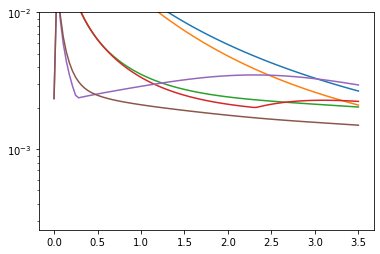

(100, 6) (-0.002956767100840807-2.1043156110228598e-35j)
Norm 1.0


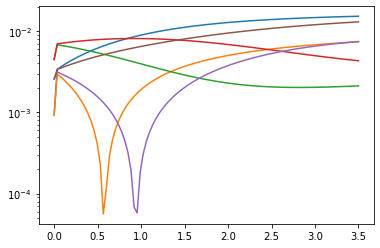

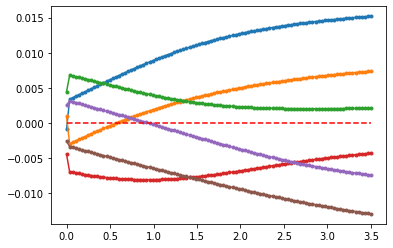

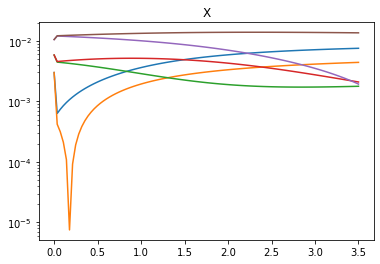

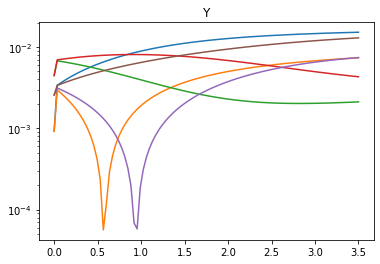

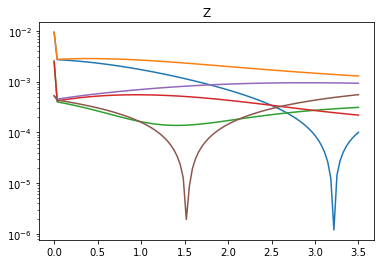

In [8]:
#Plot our energy levels
CS_S= np.abs(np.squeeze(CS_G[0,0,:,:]))
OS_Sq = (np.squeeze(OS_SG[0,0,:,:,:]))
OS_S = np.abs(OS_Sq)

print(OS_S.shape)
print(CS_S.shape)


cart =spin.sphereCart(1,thetas[0],phis[0])+off
cart/=np.linalg.norm(cart)
print("Cartesian Coords: ",cart.T)            
#print(OS_S[1,1,:],np.matrix(OS_S[1,1,:])@cart)
thres = 1E-10

plt.semilogy(Bs,CS_S)
plt.ylim([None,1E-2])
plt.show()
plt.close()
#plt.semilogy(Bs,np.linalg.norm(OS_S,axis=2),'*-')
#plt.semilogy(Bs,OS_S.reshape((len(Bs),18)),'*-')

gradCalc  = (OS_Sq)@cart

plt.semilogy(Bs,np.abs(gradCalc),'-')
print(gradCalc.shape,gradCalc[1,1])
print("Norm", np.linalg.norm(cart))
#plt.semilogy(Bs,np.ones_like(Bs)*thres,'r--')

plt.show()
plt.close()


plt.plot(Bs,np.real(gradCalc),'.-')
plt.plot(Bs,np.ones_like(Bs)*0,'r--')

plt.show()
plt.close()

#grad = np.gradient(F_S,axis=0)


# print(grad.shape)
# plt.semilogy(Bs,np.abs(grad))
# #plt.plot(Bs,grad)
# plt.title("Gradient")
# plt.show()
# plt.close()

# plt.semilogy(Bs,np.abs(np.gradient(grad,axis=1))[:,::-1])
# plt.title("Gradient of Gradient")
# plt.show()
# plt.close()


#plt.subplot(3,1,1)
plt.semilogy(Bs,OS_S[:,:,0],'-')
#plt.semilogy(Bs,np.ones_like(Bs)*thres,'r--')

plt.title("X")
plt.show()
plt.close()

#plt.subplot(3,1,2)
plt.semilogy(Bs,OS_S[:,:,1],'-')
#plt.semilogy(Bs,np.ones_like(Bs)*thres,'r--')

plt.title("Y")
plt.show()
plt.close()

#plt.subplot(3,1,3)
plt.title("Z")
plt.semilogy(Bs,OS_S[:,:,2],'-')
#plt.semilogy(Bs,np.ones_like(Bs)*thres,'r--')

plt.show()
plt.close()



#plt.ylim([None,1E-4])
#plt.semilogy(Bs,np.ones_like(Bs)*thres,'r--')

plt.show()
plt.close()


[[ 0  0]
 [ 0  1]
 [16  1]
 [26  4]]
[0.         0.         0.56565657 0.91919192]


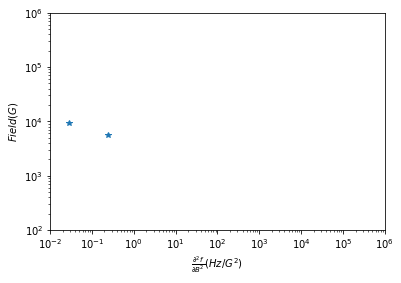

In [9]:

# tind=np.argwhere(OS_S<thres)
# print(tind)
# print(np.unique(Bs[tind[:,0]]))
# #print(CS_S[tind])

# print(CS_S.shape)

zero_crossings =lambda a: np.argwhere(np.diff(np.sign(a),axis=0))
id = (zero_crossings(gradCalc))
print(id)
print(Bs[id[:,0]])


plt.loglog(CS_S[id[:,0],id[:,1]]*1E1,Bs[id[:,0]]*1E4,'*')
plt.ylabel(r'$Field(G)$')
plt.xlabel(r"$\frac{\partial^2f}{\partial B^{2}}(Hz/G^2)$")
plt.xlim([1E-2,1E6])
plt.ylim([1E2,1E6])
plt.show()
plt.close()




In [17]:
carts = spin.sphereCart(1,thetas,phis)

print(carts.shape,OS_SG.shape)


grads= np.squeeze(OS_SG[0,0,:,:,:]@carts)

print(grads.shape)


zero_crossings =lambda a: np.argwhere(np.diff(np.sign(a),axis=2))
id = (zero_crossings(gradCalc))
print(id)
print(Bs[id[:,0]])


plt.loglog(CS_S[id[:,0],id[:,1]]*1E1,Bs[id[:,0]]*1E4,'*')
plt.ylabel(r'$Field(G)$')
plt.xlabel(r"$\frac{\partial^2f}{\partial B^{2}}(Hz/G^2)$")
plt.xlim([1E-2,1E6])
plt.ylim([1E2,1E6])
plt.show()
plt.close()




(100, 3) (100, 100, 100, 6, 3)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 100 is different from 3)